# Caution

This notebook uses the newer side-symmetric labeler and explicitly tests split long/short secondary models with dollar-neutral reweighting. The DGP is still the noisy portfolio-volatility-calibrated synthetic setup, so weak classification results should be interpreted in that context.


# Split Long/Short Secondary Testing

This notebook tests whether separate long-side and short-side secondary models improve classification and whether dollar-neutral reweighting changes the economic interpretation.

The setup intentionally mirrors the current horizon-sensitivity workflow: side-symmetric triple-barrier labels, purged time splits, fixed `0.50` probability threshold, and the `100u/200d` scenario as the first focused comparison.


In [70]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.primary_strategy import build_primary_momentum_strategy_fast
from src.triple_barrier_lsymmetric import simple_triple_barrier_labels_lsymmetric
from src.secondary_model_fast import (
    build_secondary_dataset_fast,
    purged_time_split,
    fit_logistic,
    apply_probability_threshold,
    create_filtered_weights_fast,
    calculate_strategy_pnl,
)
from src.secondary_model_split_fast import (
    build_split_secondary_dataset_fast,
    fit_split_logistic,
    create_split_filtered_weights_fast,
    create_dollar_neutral_filtered_weights,
    dollar_neutral_side_availability,
)
from src.evaluation_metrics import evaluate_strategy
from src.horizon_sensitivity import exposure_summary


In [71]:
import importlib
import src.triple_barrier_lsymmetric

importlib.reload(src.triple_barrier_lsymmetric)

<module 'src.triple_barrier_lsymmetric' from '/Users/ipacskornel/Downloads/Thesis/For github/meta_labeling_project/src/triple_barrier_lsymmetric.py'>

## Configuration

The first run is deliberately narrow. It compares pooled and split secondary models in the `100u/200d` setting, where the pooled gross-normalised model previously became short-biased.


In [72]:
n_sims = 20
base_seed = 20_000

n_up = 100
n_down = 200
scenario_name = f"{n_up}u/{n_down}d"

horizons = [30, 60, 90, 150]
lookback = 260
barrier_vol_window = 20
barrier_multiplier = 1.2
secondary_window = 150
secondary_windows = (150,)
threshold = 0.50
train_frac = 0.50
val_frac = 0.25

pooled_feature_cols = [
    "side",
    "abs_weight",
    "signed_ret_150",
    "vol_150",
]

split_feature_cols = [
    "abs_weight",
    "signed_ret_150",
    "vol_150",
]

scenario_name, horizons, pooled_feature_cols, split_feature_cols


('100u/200d',
 [30, 60, 90, 150],
 ['side', 'abs_weight', 'signed_ret_150', 'vol_150'],
 ['abs_weight', 'signed_ret_150', 'vol_150'])

## Synthetic Data Generator

This is the same data-generation structure used in the fast sensitivity notebooks. Each simulation seed changes the sampled returns and the identities/magnitudes of the up/down trend stocks, while the covariance structure is fixed.


In [73]:
component_seed = 0
rng_components = np.random.default_rng(component_seed)

N = 500
T = 10_000
K = 10

dates = pd.date_range("1986-01-01", periods=T, freq="B")
cols = [f"Stock_{i:03d}" for i in range(N)]

target_daily_vol = 0.10 / np.sqrt(252)
split = [0.6, 0.4]
trend_daily = 0.50 / 252

wi = np.ones((N, 1)) / N

Z = rng_components.normal(0, 1, size=(N, K - 1))
Z = (Z - Z.mean(axis=1, keepdims=True)) / Z.std(axis=1, keepdims=True)
Z = np.concatenate([rng_components.uniform(0.5, 1.5, size=(N, 1)), Z], axis=1)

G = np.diag(np.concatenate([np.ones(1), [0.25 * np.exp(-i) for i in range(K - 1)]]))
S = rng_components.uniform(0.01, 0.25, size=N)

multf = np.squeeze(split[0] * target_daily_vol**2 / (wi.T @ (Z @ G @ Z.T) @ wi))
mults = np.squeeze(split[1] * target_daily_vol**2 / (wi.T @ np.diag(S) @ wi))

G = multf * G
cov_factor = Z @ G @ Z.T
S = mults * S
cov_specific = np.diag(S)
cov = cov_factor + cov_specific


def generate_returns_for_seed(seed):
    rng = np.random.default_rng(seed)
    all_stocks = np.arange(N)
    up_stocks = rng.choice(N, size=n_up, replace=False)
    remaining = np.setdiff1d(all_stocks, up_stocks)
    down_stocks = rng.choice(remaining, size=n_down, replace=False)

    trend = np.zeros(N)
    trend[up_stocks] = rng.uniform(0.1, 1.0, size=n_up) * trend_daily
    trend[down_stocks] = -rng.uniform(0.1, 1.0, size=n_down) * trend_daily

    sampled_returns = rng.multivariate_normal(trend, cov, size=T)
    return pd.DataFrame(sampled_returns, index=dates, columns=cols)


## Notebook Helpers

The diagnostics are intentionally explicit. The key comparison is whether the split model improves within-side ranking, and whether dollar-neutral reweighting preserves or removes the economic gain from gross-normalised exposure tilt.


In [74]:
def metric_value(summary, metric):
    return float(summary.loc[summary["Metric"] == metric, "Value"].iloc[0])


def selected_strategy_metrics(summary):
    return {
        "ann_return": metric_value(summary, "Annualized return"),
        "avg_daily_return": metric_value(summary, "Average daily return"),
        "sharpe": metric_value(summary, "Sharpe ratio"),
        "max_drawdown": metric_value(summary, "Maximum drawdown"),
        "ann_turnover": metric_value(summary, "Annualized turnover"),
    }


def safe_roc_auc(df, target_col="label", proba_col="probability"):
    if len(df) == 0 or df[target_col].nunique() < 2:
        return np.nan
    return roc_auc_score(df[target_col], df[proba_col])


def standardize_gross_exposure(filtered_weights, primary_weights):
    primary_exposure = primary_weights.abs().sum(axis=1)
    filtered_exposure = filtered_weights.abs().sum(axis=1)
    scale = primary_exposure / filtered_exposure
    scale = scale.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return filtered_weights.mul(scale, axis=0)


def side_classification_summary(df, model_variant):
    rows = []
    out = df.copy()
    out["primary_side"] = np.where(out["side"] > 0, "long", "short")

    for primary_side, group in out.groupby("primary_side"):
        y_true = group["label"].astype(int)
        y_pred = group["meta_label"].astype(int)
        positives = y_true == 1
        negatives = y_true == 0

        rows.append({
            "model_variant": model_variant,
            "primary_side": primary_side,
            "n": len(group),
            "roc_auc": safe_roc_auc(group),
            "base_positive_rate": y_true.mean(),
            "kept_rate": y_pred.mean(),
            "positive_rate_among_kept": y_true[y_pred == 1].mean() if (y_pred == 1).any() else np.nan,
            "false_positive_rate": ((y_pred == 1) & negatives).sum() / negatives.sum() if negatives.any() else np.nan,
            "false_negative_rate": ((y_pred == 0) & positives).sum() / positives.sum() if positives.any() else np.nan,
            "avg_probability": group["probability"].mean(),
        })

    return pd.DataFrame(rows)


def overall_classification_summary(df, model_variant):
    y_true = df["label"].astype(int)
    y_pred = df["meta_label"].astype(int)
    negatives = y_true == 0
    positives = y_true == 1

    return {
        "model_variant": model_variant,
        "roc_auc": safe_roc_auc(df),
        "base_positive_rate": y_true.mean(),
        "kept_rate": y_pred.mean(),
        "positive_rate_among_kept": y_true[y_pred == 1].mean() if (y_pred == 1).any() else np.nan,
        "false_positive_rate": ((y_pred == 1) & negatives).sum() / negatives.sum() if negatives.any() else np.nan,
        "false_negative_rate": ((y_pred == 0) & positives).sum() / positives.sum() if positives.any() else np.nan,
    }


def evaluate_weight_variant(model_variant, weights, df_returns, primary_metrics, sim, seed, horizon):
    pnl = calculate_strategy_pnl(weights, df_returns)
    summary = evaluate_strategy(pnl, weights)
    metrics = selected_strategy_metrics(summary)

    row = {
        "scenario": scenario_name,
        "sim": sim,
        "seed": seed,
        "horizon": horizon,
        "model_variant": model_variant,
        **metrics,
    }
    row["delta_ann_return"] = row["ann_return"] - primary_metrics["ann_return"]
    row["delta_sharpe"] = row["sharpe"] - primary_metrics["sharpe"]
    row["delta_max_drawdown"] = row["max_drawdown"] - primary_metrics["max_drawdown"]
    row["delta_ann_turnover"] = row["ann_turnover"] - primary_metrics["ann_turnover"]
    return row


def exposure_row(model_variant, weights, sim, seed, horizon):
    exposure = exposure_summary(weights).mean().to_dict()
    return {
        "scenario": scenario_name,
        "sim": sim,
        "seed": seed,
        "horizon": horizon,
        "model_variant": model_variant,
        **exposure,
    }


## Single-Horizon Pipeline

For each seed and horizon, the function below creates one label set, then fits both the pooled model and the split long/short model on the same train/validation/test split.


In [75]:
def run_one_horizon_sim(sim, seed, horizon, df_returns, primary_pnl, primary_weights):
    labels = simple_triple_barrier_labels_lsymmetric(
        df_returns=df_returns,
        wt=primary_weights,
        horizon=horizon,
        vol_window=barrier_vol_window,
        barrier_multiplier=barrier_multiplier,
    )

    secondary_data = build_split_secondary_dataset_fast(
        df_returns=df_returns,
        labels=labels,
        window=secondary_window,
        windows=secondary_windows,
    )

    train_df, val_df, test_df, _, _ = purged_time_split(
        df=secondary_data,
        horizon=horizon,
        train_frac=train_frac,
        val_frac=val_frac,
    )

    _, _, _, pooled_test = fit_logistic(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        feature_cols=pooled_feature_cols,
    )
    pooled_test = apply_probability_threshold(pooled_test, threshold)

    _, _, _, split_test = fit_split_logistic(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        feature_cols=split_feature_cols,
    )
    split_test = apply_probability_threshold(split_test, threshold)

    test_dates = pd.Index(test_df["t0"].unique())
    test_dates = test_dates.intersection(primary_weights.index).intersection(df_returns.index).sort_values()
    pooled_test = pooled_test[pooled_test["t0"].isin(test_dates)].copy()
    split_test = split_test[split_test["t0"].isin(test_dates)].copy()

    primary_test_weights = primary_weights.reindex(test_dates)
    primary_test_pnl = calculate_strategy_pnl(primary_test_weights, df_returns)
    primary_metrics = selected_strategy_metrics(evaluate_strategy(primary_test_pnl, primary_test_weights))

    pooled_raw = create_filtered_weights_fast(primary_test_weights, pooled_test)
    pooled_gross = standardize_gross_exposure(pooled_raw, primary_test_weights)

    split_raw = create_split_filtered_weights_fast(primary_test_weights, split_test)
    split_gross = standardize_gross_exposure(split_raw, primary_test_weights)
    split_dollar_neutral = create_dollar_neutral_filtered_weights(primary_test_weights, split_test)

    classification_rows = [
        {
            "scenario": scenario_name,
            "sim": sim,
            "seed": seed,
            "horizon": horizon,
            **overall_classification_summary(pooled_test, "pooled"),
        },
        {
            "scenario": scenario_name,
            "sim": sim,
            "seed": seed,
            "horizon": horizon,
            **overall_classification_summary(split_test, "split_overall"),
        },
    ]

    side_rows = []
    for model_variant, pred_df in [("pooled", pooled_test), ("split", split_test)]:
        side_summary = side_classification_summary(pred_df, model_variant)
        side_summary.insert(0, "horizon", horizon)
        side_summary.insert(0, "seed", seed)
        side_summary.insert(0, "sim", sim)
        side_summary.insert(0, "scenario", scenario_name)
        side_rows.append(side_summary)

    strategy_rows = [
        {
            "scenario": scenario_name,
            "sim": sim,
            "seed": seed,
            "horizon": horizon,
            "model_variant": "primary",
            **primary_metrics,
            "delta_ann_return": 0.0,
            "delta_sharpe": 0.0,
            "delta_max_drawdown": 0.0,
            "delta_ann_turnover": 0.0,
        },
        evaluate_weight_variant("pooled_gross", pooled_gross, df_returns, primary_metrics, sim, seed, horizon),
        evaluate_weight_variant("split_gross", split_gross, df_returns, primary_metrics, sim, seed, horizon),
        evaluate_weight_variant("split_dollar_neutral", split_dollar_neutral, df_returns, primary_metrics, sim, seed, horizon),
    ]

    exposure_rows = [
        exposure_row("primary", primary_test_weights, sim, seed, horizon),
        exposure_row("pooled_gross", pooled_gross, sim, seed, horizon),
        exposure_row("split_gross", split_gross, sim, seed, horizon),
        exposure_row("split_dollar_neutral", split_dollar_neutral, sim, seed, horizon),
    ]

    availability = dollar_neutral_side_availability(split_raw)
    availability_row = {
        "scenario": scenario_name,
        "sim": sim,
        "seed": seed,
        "horizon": horizon,
        **availability,
    }

    return {
        "classification": pd.DataFrame(classification_rows),
        "side": pd.concat(side_rows, ignore_index=True),
        "strategy": pd.DataFrame(strategy_rows),
        "exposure": pd.DataFrame(exposure_rows),
        "availability": pd.DataFrame([availability_row]),
    }


## Simulation Loop

The loop reuses the same return matrix for all horizons within a simulation seed, so horizon differences are not caused by different random samples.


In [76]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import importlib
import src.secondary_model_split_fast

importlib.reload(src.secondary_model_split_fast)

import src.secondary_model_fast

importlib.reload(src.secondary_model_fast)

<module 'src.secondary_model_fast' from '/Users/ipacskornel/Downloads/Thesis/For github/meta_labeling_project/src/secondary_model_fast.py'>

In [77]:
classification_parts = []
side_parts = []
strategy_parts = []
exposure_parts = []
availability_parts = []

total_runs = n_sims * len(horizons)
completed_runs = 0

for sim in range(n_sims):
    seed = base_seed + sim
    df_returns = generate_returns_for_seed(seed)
    primary_pnl, primary_weights, _ = build_primary_momentum_strategy_fast(df_returns, lookback=lookback)

    for horizon in horizons:
        result = run_one_horizon_sim(
            sim=sim,
            seed=seed,
            horizon=horizon,
            df_returns=df_returns,
            primary_pnl=primary_pnl,
            primary_weights=primary_weights,
        )

        classification_parts.append(result["classification"])
        side_parts.append(result["side"])
        strategy_parts.append(result["strategy"])
        exposure_parts.append(result["exposure"])
        availability_parts.append(result["availability"])

        completed_runs += 1
        if completed_runs % max(1, total_runs // 10) == 0:
            print(f"completed {completed_runs}/{total_runs}")

classification_results = pd.concat(classification_parts, ignore_index=True)
side_results = pd.concat(side_parts, ignore_index=True)
strategy_results = pd.concat(strategy_parts, ignore_index=True)
exposure_results = pd.concat(exposure_parts, ignore_index=True)
availability_results = pd.concat(availability_parts, ignore_index=True)

classification_results.head(), strategy_results.head()


completed 8/80
completed 16/80
completed 24/80
completed 32/80
completed 40/80
completed 48/80
completed 56/80
completed 64/80
completed 72/80
completed 80/80


(    scenario  sim   seed  horizon  model_variant   roc_auc  \
 0  100u/200d    0  20000       30         pooled  0.505842   
 1  100u/200d    0  20000       30  split_overall  0.500212   
 2  100u/200d    0  20000       60         pooled  0.509497   
 3  100u/200d    0  20000       60  split_overall  0.505001   
 4  100u/200d    0  20000       90         pooled  0.514610   
 
    base_positive_rate  kept_rate  positive_rate_among_kept  \
 0            0.237841   0.507498                  0.241939   
 1            0.237841   0.436229                  0.235922   
 2            0.253482   0.489419                  0.259756   
 3            0.253482   0.446961                  0.254161   
 4            0.260608   0.481658                  0.270330   
 
    false_positive_rate  false_negative_rate  
 0             0.504769             0.483759  
 1             0.437327             0.567291  
 2             0.485305             0.498466  
 3             0.446555             0.551842  
 4   

## Classification Comparison

If the split architecture helps, the split model should improve both overall ROC AUC and side-specific ROC AUC. If the values remain close to the pooled model, the current feature set is likely the limiting factor.


In [78]:
classification_summary = (
    classification_results
    .groupby(["horizon", "model_variant"])[[
        "roc_auc",
        "base_positive_rate",
        "kept_rate",
        "positive_rate_among_kept",
        "false_positive_rate",
        "false_negative_rate",
    ]]
    .agg(["mean", "std"])
)
classification_summary


roc_auc           base_positive_rate            \
                           mean       std               mean       std   
horizon model_variant                                                    
30      pooled         0.508178  0.003862           0.238460  0.001216   
        split_overall  0.504469  0.002509           0.238460  0.001216   
60      pooled         0.513294  0.004726           0.254984  0.001988   
        split_overall  0.508464  0.003471           0.254984  0.001988   
90      pooled         0.518598  0.005399           0.261905  0.002278   
        split_overall  0.513736  0.004225           0.261905  0.002278   
150     pooled         0.527484  0.006422           0.267236  0.003015   
        split_overall  0.522218  0.005476           0.267236  0.003015   

                      kept_rate           positive_rate_among_kept            \
                           mean       std                     mean       std   
horizon model_variant                                                          
30      pooled         0.492513  0.033080                 0.242899  0.002634   
        split_overall  0.449718  0.014536                 0.240906  0.002295   
60      pooled         0.485643  0.024186                 0.262358  0.003363   
        split_overall  0.453536  0.013811                 0.259809  0.003235   
90      pooled         0.479501  0.017156                 0.272460  0.003917   
        split_overall  0.455194  0.008601                 0.269976  0.003314   
150     pooled         0.472657  0.015143                 0.282928  0.005092   
        split_overall  0.456352  0.007277                 0.280576  0.004512   

                      false_positive_rate           false_negative_rate  \
                                     mean       std                mean   
horizon model_variant                                                     
30      pooled                   0.489600  0.032311            0.498185   
        split_overall            0.448276  0.014656            0.545677   
60      pooled                   0.480812  0.023491            0.500238   
        split_overall            0.450607  0.014123            0.537912   
90      pooled                   0.472628  0.016544            0.501121   
        split_overall            0.450222  0.008916            0.530793   
150     pooled                   0.462518  0.014467            0.499531   
        split_overall            0.448048  0.007705            0.520867   

                                 
                            std  
horizon model_variant            
30      pooled         0.035906  
        split_overall  0.014761  
60      pooled         0.026924  
        split_overall  0.013613  
90      pooled         0.020191  
        split_overall  0.008982  
150     pooled         0.019258  
        split_overall  0.009611

In [79]:
side_summary = (
    side_results
    .groupby(["horizon", "model_variant", "primary_side"])[[
        "roc_auc",
        "base_positive_rate",
        "kept_rate",
        "positive_rate_among_kept",
        "false_positive_rate",
        "false_negative_rate",
        "avg_probability",
    ]]
    .mean()
)
side_summary


roc_auc  base_positive_rate  kept_rate  \
horizon model_variant primary_side                                            
30      pooled        long          0.502744            0.233657   0.168280   
                      short         0.505609            0.243258   0.815800   
        split         long          0.503014            0.233657   0.438274   
                      short         0.505929            0.243258   0.461170   
60      pooled        long          0.506059            0.247885   0.207205   
                      short         0.511391            0.262072   0.763236   
        split         long          0.505507            0.247885   0.446533   
                      short         0.511263            0.262072   0.460548   
90      pooled        long          0.510403            0.253204   0.235280   
                      short         0.517386            0.270592   0.722926   
        split         long          0.510073            0.253204   0.448811   
                      short         0.517301            0.270592   0.461558   
150     pooled        long          0.517793            0.256167   0.267365   
                      short         0.527368            0.278290   0.677294   
        split         long          0.517212            0.256167   0.453721   
                      short         0.527262            0.278290   0.458985   

                                    positive_rate_among_kept  \
horizon model_variant primary_side                             
30      pooled        long                          0.240311   
                      short                         0.244124   
        split         long                          0.235113   
                      short                         0.246328   
60      pooled        long                          0.257200   
                      short                         0.264573   
        split         long                          0.250779   
                      short                         0.268459   
90      pooled        long                          0.269369   
                      short                         0.275530   
        split         long                          0.258581   
                      short                         0.280926   
150     pooled        long                          0.274717   
                      short                         0.287419   
        split         long                          0.265604   
                      short                         0.295256   

                                    false_positive_rate  false_negative_rate  \
horizon model_variant primary_side                                             
30      pooled        long                     0.167364             0.828721   
                      short                    0.814999             0.181699   
        split         long                     0.437458             0.559063   
                      short                    0.459269             0.532946   
60      pooled        long                     0.205230             0.786838   
                      short                    0.761010             0.230494   
        split         long                     0.444826             0.548330   
                      short                    0.456541             0.528215   
90      pooled        long                     0.231930             0.754934   
                      short                    0.718529             0.265239   
        split         long                     0.445564             0.541697   
                      short                    0.455007             0.520865   
150     pooled        long                     0.261605             0.716071   
                      short                    0.669332             0.302080   
        split         long                     0.447939             0.529657   
                      short                    0.448181             0.513076   

                    

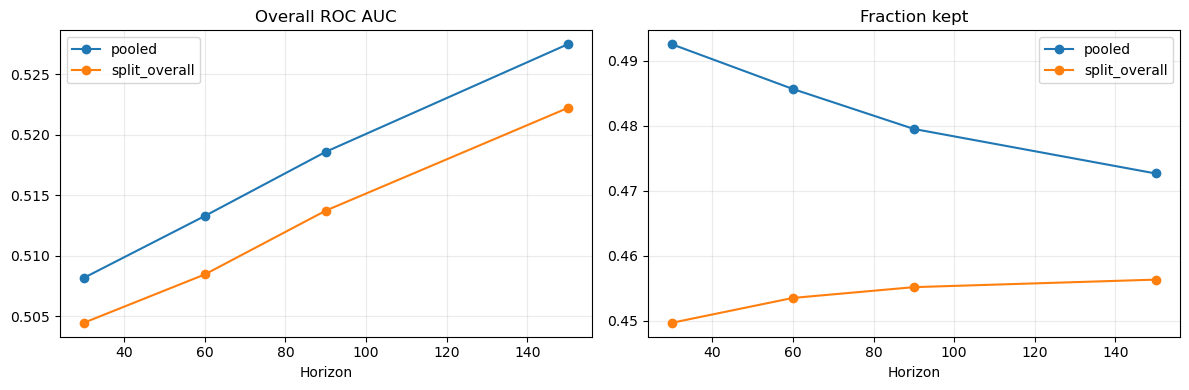

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model_variant in classification_results["model_variant"].unique():
    data = classification_results[classification_results["model_variant"] == model_variant]
    means = data.groupby("horizon")["roc_auc"].mean()
    axes[0].plot(means.index, means.values, marker="o", label=model_variant)
    means = data.groupby("horizon")["kept_rate"].mean()
    axes[1].plot(means.index, means.values, marker="o", label=model_variant)

axes[0].set_title("Overall ROC AUC")
axes[1].set_title("Fraction kept")
for ax in axes:
    ax.set_xlabel("Horizon")
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()


## Strategy And Exposure Comparison

The dollar-neutral strategy should show whether the economic improvement survives after removing gross-normalised long/short exposure drift.


In [81]:
strategy_summary = (
    strategy_results
    .groupby(["horizon", "model_variant"])[[
        "ann_return",
        "sharpe",
        "max_drawdown",
        "ann_turnover",
        "delta_ann_return",
        "delta_sharpe",
        "delta_max_drawdown",
        "delta_ann_turnover",
    ]]
    .agg(["mean", "std"])
)
strategy_summary


ann_return              sharpe            \
                                   mean       std      mean       std   
horizon model_variant                                                   
30      pooled_gross           0.092906  0.040026  0.845193  0.302103   
        primary                0.050217  0.018588  0.660043  0.223168   
        split_dollar_neutral   0.056352  0.031467  0.602701  0.309693   
        split_gross            0.053774  0.031722  0.569514  0.302050   
60      pooled_gross           0.095138  0.036261  0.888433  0.267799   
        primary                0.050359  0.017594  0.661540  0.211420   
        split_dollar_neutral   0.061151  0.025449  0.655808  0.245837   
        split_gross            0.056414  0.028454  0.601699  0.273601   
90      pooled_gross           0.094410  0.031465  0.904229  0.240650   
        primary                0.050349  0.018173  0.661116  0.218111   
        split_dollar_neutral   0.062518  0.023792  0.676550  0.233971   
        split_gross            0.057983  0.027209  0.624288  0.266620   
150     pooled_gross           0.090497  0.033237  0.889822  0.268580   
        primary                0.048755  0.018555  0.641683  0.222580   
        split_dollar_neutral   0.066296  0.022370  0.722081  0.218530   
        split_gross            0.061566  0.024819  0.667800  0.243549   

                             max_drawdown           ann_turnover            \
                                     mean       std         mean       std   
horizon model_variant                                                        
30      pooled_gross            -0.179712  0.046112    12.592660  0.738362   
        primary                 -0.150228  0.024406    10.836641  0.071289   
        split_dollar_neutral    -0.208457  0.045190    13.409836  0.743866   
        split_gross             -0.221228  0.048908    13.290401  0.719611   
60      pooled_gross            -0.170505  0.033925    12.673683  0.660549   
        primary                 -0.150228  0.024406    10.838424  0.069592   
        split_dollar_neutral    -0.192334  0.036169    13.300865  0.688495   
        split_gross             -0.209807  0.052412    13.201997  0.660395   
90      pooled_gross            -0.163990  0.032368    12.704208  0.544976   
        primary                 -0.150279  0.024333    10.840670  0.068955   
        split_dollar_neutral    -0.184313  0.040691    13.299522  0.594030   
        split_gross             -0.201908  0.055972    13.213188  0.579928   
150     pooled_gross            -0.170404  0.029445    12.654883  0.494578   
        primary                 -0.150279  0.024333    10.844424  0.069063   
        split_dollar_neutral    -0.178206  0.041087    13.241851  0.606563   
        split_gross             -0.194534  0.049728    13.154131  0.596787   

                             delta_ann_return           delta_sharpe  \
                                         mean       std         mean   
horizon model_variant                                                  
30      pooled_gross                 0.042689  0.033975     0.185150   
        primary                      0.000000  0.000000     0.000000   
        split_dollar_neutral         0.006135  0.020827    -0.057342   
        split_gross                  0.003557  0.021638    -0.090529   
60      pooled_gross                 0.044779  0.031790     0.226893   
        primary                      0.000000  0.000000     0.000000   
        split_dollar_neutral         0.010792  0.013798    -0.005732   
        split_gross                  0.006055  0.018673    -0.059841   
90      pooled_gross                 0.044061  0.029307     0.243113   
        primary                      0.000000  0.000000     0.000000   
        split_dollar_neutral         0.012169  0.014139     0.015434   
        split_gross                  0.007634  0.019811    -0.036827   
150     pooled_gross                 0.041742  0.032539     0.248139   
      

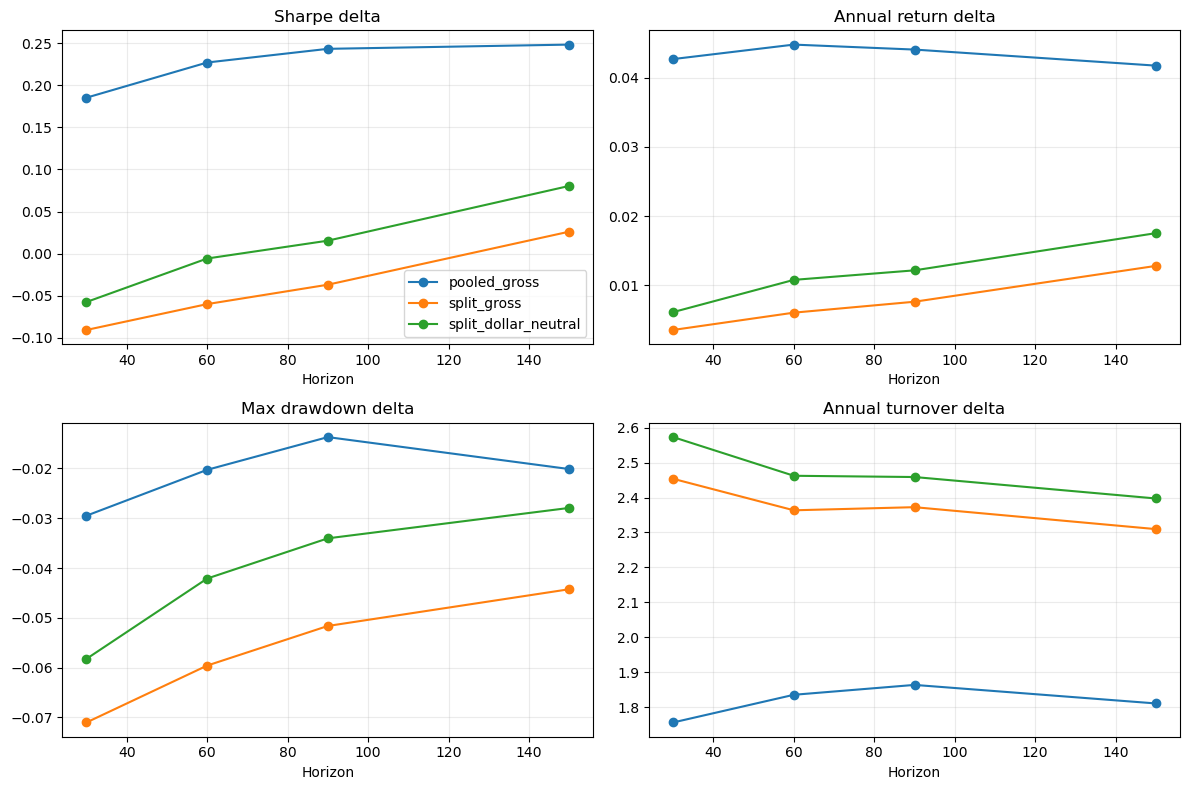

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_cols = [
    ("delta_sharpe", "Sharpe delta"),
    ("delta_ann_return", "Annual return delta"),
    ("delta_max_drawdown", "Max drawdown delta"),
    ("delta_ann_turnover", "Annual turnover delta"),
]

for ax, (col, title) in zip(axes.ravel(), plot_cols):
    for model_variant in ["pooled_gross", "split_gross", "split_dollar_neutral"]:
        data = strategy_results[strategy_results["model_variant"] == model_variant]
        means = data.groupby("horizon")[col].mean()
        ax.plot(means.index, means.values, marker="o", label=model_variant)
    ax.set_title(title)
    ax.set_xlabel("Horizon")
    ax.grid(alpha=0.25)

axes[0, 0].legend()
plt.tight_layout()
plt.show()


In [83]:
exposure_summary_table = (
    exposure_results
    .groupby(["horizon", "model_variant"])[[
        "net_exposure",
        "gross_exposure",
        "long_exposure",
        "short_exposure",
        "long_gross_share",
        "short_gross_share",
    ]]
    .mean()
)
exposure_summary_table


net_exposure  gross_exposure  long_exposure  \
horizon model_variant                                                       
30      pooled_gross         -4.963831e-01             1.0       0.251808   
        primary              -3.012552e-20             1.0       0.500000   
        split_dollar_neutral -5.670131e-19             1.0       0.500000   
        split_gross           2.548194e-02             1.0       0.512741   
60      pooled_gross         -4.409981e-01             1.0       0.279501   
        primary              -3.889326e-20             1.0       0.500000   
        split_dollar_neutral  4.312938e-19             1.0       0.500000   
        split_gross           4.080670e-02             1.0       0.520403   
90      pooled_gross         -4.029598e-01             1.0       0.298520   
        primary              -2.326405e-20             1.0       0.500000   
        split_dollar_neutral  3.916395e-20             1.0       0.500000   
        split_gross           4.381545e-02             1.0       0.521908   
150     pooled_gross         -3.589810e-01             1.0       0.320509   
        primary              -3.967784e-20             1.0       0.500000   
        split_dollar_neutral -7.617069e-19             1.0       0.500000   
        split_gross           4.471946e-02             1.0       0.522360   

                              short_exposure  long_gross_share  \
horizon model_variant                                            
30      pooled_gross               -0.748192          0.251808   
        primary                    -0.500000          0.500000   
        split_dollar_neutral       -0.500000          0.500000   
        split_gross                -0.487259          0.512741   
60      pooled_gross               -0.720499          0.279501   
        primary                    -0.500000          0.500000   
        split_dollar_neutral       -0.500000          0.500000   
        split_gross                -0.479597          0.520403   
90      pooled_gross               -0.701480          0.298520   
        primary                    -0.500000          0.500000   
        split_dollar_neutral       -0.500000          0.500000   
        split_gross                -0.478092          0.521908   
150     pooled_gross               -0.679491          0.320509   
        primary                    -0.500000          0.500000   
        split_dollar_neutral       -0.500000          0.500000   
        split_gross                -0.477640          0.522360   

                              short_gross_share  
horizon model_variant                            
30      pooled_gross                   0.748192  
        primary                        0.500000  
        split_dollar_neutral           0.500000  
        split_gross                    0.487259  
60      pooled_gross                   0.720499  
        primary                        0.500000  
        split_dollar_neutral           0.500000  
        split_gross                    0.479597  
90      pooled_gross                   0.701480  
        primary                        0.500000  
        split_dollar_neutral           0.500000  
        split_gross                    0.478092  
150     pooled_gross                   0.679491  
        primary                        0.500000  
        split_dollar_neutral           0.500000  
        split_gross                    0.477640

In [84]:
availability_summary = (
    availability_results
    .groupby("horizon")[[
        "long_present_rate",
        "short_present_rate",
        "both_sides_present_rate",
        "missing_long_rate",
        "missing_short_rate",
    ]]
    .mean()
)
availability_summary


,long_present_rate,short_present_rate,both_sides_present_rate,missing_long_rate,missing_short_rate
horizon,,,,,
30,1.0,1.0,1.0,0.0,0.0
60,1.0,1.0,1.0,0.0,0.0
90,1.0,1.0,1.0,0.0,0.0
150,1.0,1.0,1.0,0.0,0.0


## Interpretation Checklist

- If split ROC AUC is materially above pooled ROC AUC, then the pooled model architecture was hiding side-specific relationships.
- If split ROC AUC remains close to pooled ROC AUC, then the current features are likely too weak for strong classification.
- If split gross performs well but split dollar-neutral does not, then the economic gain mostly comes from exposure tilt.
- If split dollar-neutral performs well, then the secondary model is adding value even after enforcing long/short balance.
